Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Preprocessing completed.

(a) TRAIN-TEST SPLIT
Training samples: 40000
Testing samples : 10000

TF-IDF created.
Unigram features: 50000
Unigram + Bigram features: 50000

(b) & (c) RESULTS FOR DIFFERENT C VALUES


,C,Accuracy,Precision,Recall,F1-score
0,0.01,0.8749,0.8555,0.9022,0.8782
1,0.10,0.9030,0.8920,0.9170,0.9043
2,1.00,0.9055,0.9000,0.9124,0.9061
3,10.00,0.8955,0.8924,0.8994,0.8959



(d) BEST C VALUE: 1.0


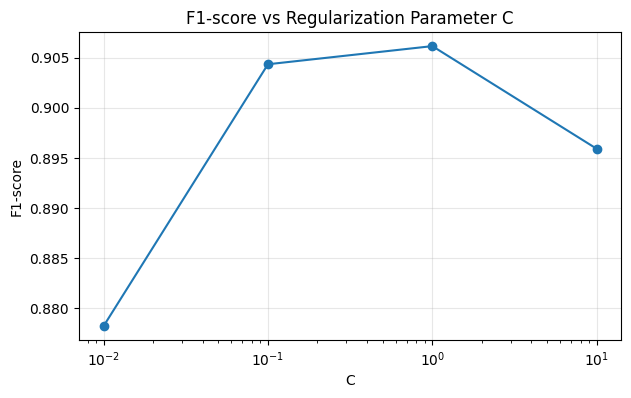


(e) UNIGRAM vs UNIGRAM + BIGRAM


,Representation,Accuracy,Precision,Recall,F1-score
0,Unigram TF-IDF,0.9011,0.8964,0.9070,0.9017
1,Unigram + Bigram TF-IDF,0.9055,0.9000,0.9124,0.9061



(f) & (g) TOP 10 POSITIVE FEATURES


,Feature,Coefficient
0,excellent,3.5940
1,perfect,3.2439
2,great,3.1912
3,must see,2.6543
4,amazing,2.6280
5,hilarious,2.6248
6,well worth,2.5493
7,wonderful,2.4780
8,enjoyable,2.4493
9,perfectly,2.3940



TOP 10 NEGATIVE FEATURES


,Feature,Coefficient
0,worst,-4.9463
1,awful,-4.3351
2,waste,-4.0732
3,boring,-3.5687
4,fails,-3.5401
5,bad,-3.4164
6,disappointing,-3.2282
7,horrible,-3.0337
8,terrible,-2.9761
9,disappointment,-2.9606



(h) INTERPRETATION

Positive features generally have positive SVM coefficients,
meaning they push the prediction toward positive sentiment.

Negative features have negative coefficients,
meaning they push the prediction toward negative sentiment.

If words/phrases such as 'excellent', 'amazing', 'wonderful',
'best' appear among positive features and words/phrases such as
'worst', 'boring', 'terrible', 'waste' appear among negative
features, the learned features make intuitive sense.

Some neutral-looking words or phrases may also appear because
the model learns statistical associations from the training data.


(i) FIVE MISCLASSIFIED REVIEWS WITH STRONG FEATURES


,Review,Actual,Predicted,Strong features present
0,"I am quite a fan of novelist/screenwriter Michael Chabon. His novel ""Wonder Boys"" became a fantastic movie by Curtis Hanson. His masterful novel ""The Amazing Adventures of Kavalier and Clay"" won the Pulitzer Prize a few years back, and he had a hand in the script of ""Spider Man 2"", arguably the greatest comic book movie of all time.<br /><br />Director Rawson Marshall Thurber has also directed wonderful comedic pieces, such as the gut-busting ""Dodgeball"" and the genius short film series ""Terry Tate: Office Linebacker"". And with a cast including Peter Saarsgard, Sienna Miller, Nick Nolte an...",Negative,Positive,"amazing, wonderful, worst"
1,"1. I've seen Branaghs Hamlet: Branagh is too old, speaks frequently with a high pitched voice (unwillingly funny!) - not a convincing Hamlet, and his directors qualities - poor ! (see also much ado about nothing from Branagh - the funny parts of the dialogues have mostly been cut out not speaking of the directors mistakes in the dialogue cuts!) 2. I've seen Hamlet 2000: I think the scenario is an interesting idea - but such lousy actors - all of them 3. Orson Welles Hamlet is OK - but this BBC Hamlet is the best! Derec Jacobi is convincing - seems a bit of a lunatic - very suitable! and Pa...",Positive,Negative,wonderful
2,"Ladies and gentlemen, we've really got ourselves a winner here. Actually we don't, but boy is this film an often hilarious and always entertaining horrible hoot of a stinker. Poor Alma (fetching Julia Ruiz) is suffering from an ancient Mayan curse that causes lethal poisonous snakes to grow inside of her body. Alma and her deranged shaman husband Brujo (Alby Castro, who feverishly overacts with delicious eye-rolling intensity) stowaway on a train that's bound for Los Angeles. Naturally, a bunch of deadly vipers get lose so they can terrorize the motley assortment of passengers. The Mallach...",Positive,Negative,"horrible, hilarious"
3,"Citizen Kane....The Godfather Part II....D'Urville Martin's Dolemite. This is the single greatest piece of celluloid ever created and unleashed upon humanity. Rudy Ray Moore, in a role that transcends Academy Awards stars as Dolemite, the baddest cat in the universe. He clearly does not take any jive from no turkey (I myself am unfortunately a turkey) and proves it with his powers of rapping, pimping, and karate chopping. This is blaxploitation at its absolute finest, a shining example of the genre with its low budget, continuity errors, and hatred for rat-soup eating honkey expletive expl...",Positive,Negative,awful
4,"In my opinion of this movie the entire video portion of this movie was absolute trash!!!! However the soundtrack that was used contained the music of a great heavy metal rock band, I recognized the music as being a band called Firstryke and the album was ""Just a Nightmare"" and it was very well written!! and I am curious to see what the rest of you movie buffs out there think of it, if can remember back that far I would appreciate the feed back, I collect old movie, and obscure movie sound tracks. It is a very time consuming hobby but is very rewarding. I have seen this bands music being so...",Negative,Positive,"great, bad"



ERROR ANALYSIS

Review 1
Actual: Negative
Predicted: Positive
Strong features: amazing, wonderful, worst

Possible reason:
The SVM relies heavily on individual words or short phrases.
A strong sentiment word can therefore push the prediction in
the wrong direction when the overall context is different.

Possible causes include negation, sarcasm, mixed sentiment,
contrast between different parts of the review, or a strong
word being used in an unexpected context.

Review: I am quite a fan of novelist/screenwriter Michael Chabon. His novel "Wonder Boys" became a fantastic movie by Curtis Hanson. His masterful novel "The Amazing Adventures of Kavalier and Clay" won the Pulitzer Prize a few years back, and he had a hand in the script of "Spider Man 2", arguably the greatest comic book movie of all time.<br /><br />Director Rawson Marshall Thurber has also directed wonderful comedic pieces, such as the gut-busting "Dodgeball" and the genius short film series "Terry Tate: Office Linebacker"

In [1]:
## ============================================================
# Q2: IMDb Sentiment Classification using Linear SVM
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. Load IMDb Dataset
# ------------------------------------------------------------

file_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())


# ------------------------------------------------------------
# 2. Preprocessing
# lowercase + remove HTML/URLs + tokenization
# + stopword removal + lemmatization
# ------------------------------------------------------------

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)

    words = re.findall(r"[a-z]+", text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["preprocessed_text"] = df["review"].apply(preprocess)

df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print("\nPreprocessing completed.")


# ------------------------------------------------------------
# (a) Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df["preprocessed_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("\n(a) TRAIN-TEST SPLIT")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ------------------------------------------------------------
# TF-IDF REPRESENTATIONS
# ------------------------------------------------------------

# Unigrams
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=50000
)

X_train_uni = tfidf_uni.fit_transform(X_train)
X_test_uni = tfidf_uni.transform(X_test)

# Unigrams + Bigrams
tfidf_bi = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000
)

X_train_bi = tfidf_bi.fit_transform(X_train)
X_test_bi = tfidf_bi.transform(X_test)

print("\nTF-IDF created.")
print("Unigram features:", X_train_uni.shape[1])
print("Unigram + Bigram features:", X_train_bi.shape[1])


# ------------------------------------------------------------
# (a), (b), (c)
# Linear SVM with different C values
# ------------------------------------------------------------

C_values = [0.01, 0.1, 1, 10]

svm_results = []

for C in C_values:

    svm = LinearSVC(C=C, random_state=42)
    svm.fit(X_train_bi, y_train)

    pred = svm.predict(X_test_bi)

    svm_results.append([
        C,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

svm_results = pd.DataFrame(
    svm_results,
    columns=["C", "Accuracy", "Precision", "Recall", "F1-score"]
)

print("\n(b) & (c) RESULTS FOR DIFFERENT C VALUES")
display(svm_results.round(4))


# ------------------------------------------------------------
# (d) Plot F1-score against C
# ------------------------------------------------------------

best_C = svm_results.loc[
    svm_results["F1-score"].idxmax(), "C"
]

print("\n(d) BEST C VALUE:", best_C)

plt.figure(figsize=(7, 4))
plt.plot(
    svm_results["C"],
    svm_results["F1-score"],
    marker="o"
)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("F1-score")
plt.title("F1-score vs Regularization Parameter C")
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# (e) Compare Unigram vs Unigram + Bigram
# ------------------------------------------------------------

svm_uni = LinearSVC(C=best_C, random_state=42)
svm_bi = LinearSVC(C=best_C, random_state=42)

svm_uni.fit(X_train_uni, y_train)
svm_bi.fit(X_train_bi, y_train)

pred_uni = svm_uni.predict(X_test_uni)
pred_bi = svm_bi.predict(X_test_bi)

representation_results = pd.DataFrame([
    [
        "Unigram TF-IDF",
        accuracy_score(y_test, pred_uni),
        precision_score(y_test, pred_uni),
        recall_score(y_test, pred_uni),
        f1_score(y_test, pred_uni)
    ],
    [
        "Unigram + Bigram TF-IDF",
        accuracy_score(y_test, pred_bi),
        precision_score(y_test, pred_bi),
        recall_score(y_test, pred_bi),
        f1_score(y_test, pred_bi)
    ]
],
columns=[
    "Representation",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
])

print("\n(e) UNIGRAM vs UNIGRAM + BIGRAM")
display(representation_results.round(4))


# ------------------------------------------------------------
# (f), (g)
# 10 strongest positive and negative features
# ------------------------------------------------------------

feature_names = tfidf_bi.get_feature_names_out()
coefficients = svm_bi.coef_[0]

# Strongest positive
positive_idx = np.argsort(coefficients)[-10:][::-1]

# Strongest negative
negative_idx = np.argsort(coefficients)[:10]

positive_features = pd.DataFrame({
    "Feature": feature_names[positive_idx],
    "Coefficient": coefficients[positive_idx]
})

negative_features = pd.DataFrame({
    "Feature": feature_names[negative_idx],
    "Coefficient": coefficients[negative_idx]
})

print("\n(f) & (g) TOP 10 POSITIVE FEATURES")
display(positive_features.round(4))

print("\nTOP 10 NEGATIVE FEATURES")
display(negative_features.round(4))


# ------------------------------------------------------------
# (h) Do the influential features make intuitive sense?
# ------------------------------------------------------------

print("\n(h) INTERPRETATION")

print("""
Positive features generally have positive SVM coefficients,
meaning they push the prediction toward positive sentiment.

Negative features have negative coefficients,
meaning they push the prediction toward negative sentiment.

If words/phrases such as 'excellent', 'amazing', 'wonderful',
'best' appear among positive features and words/phrases such as
'worst', 'boring', 'terrible', 'waste' appear among negative
features, the learned features make intuitive sense.

Some neutral-looking words or phrases may also appear because
the model learns statistical associations from the training data.
""")


# ------------------------------------------------------------
# (i) Find 5 incorrectly classified reviews containing
# strong positive/negative features
# ------------------------------------------------------------

# Strongest features from both classes
strong_features = set(
    feature_names[positive_idx]
).union(
    set(feature_names[negative_idx])
)

# Check incorrect predictions
wrong_indices = np.where(pred_bi != y_test.values)[0]

error_rows = []

for i in wrong_indices:

    review = X_test.iloc[i]

    # Find influential features appearing in this review
    review_words = set(review.split())
    matched = strong_features.intersection(review_words)

    if len(matched) > 0:

        error_rows.append({
            "Review": df.loc[X_test.index[i], "review"],
            "Actual": "Positive" if y_test.iloc[i] == 1 else "Negative",
            "Predicted": "Positive" if pred_bi[i] == 1 else "Negative",
            "Strong features present": ", ".join(matched)
        })

    if len(error_rows) == 5:
        break

error_df = pd.DataFrame(error_rows)

print("\n(i) FIVE MISCLASSIFIED REVIEWS WITH STRONG FEATURES")

pd.set_option("display.max_colwidth", 600)
display(error_df)


# ------------------------------------------------------------
# Error analysis
# ------------------------------------------------------------

print("\nERROR ANALYSIS")

for i, row in error_df.iterrows():

    print(f"\nReview {i+1}")
    print("Actual:", row["Actual"])
    print("Predicted:", row["Predicted"])
    print("Strong features:", row["Strong features present"])

    print("""
Possible reason:
The SVM relies heavily on individual words or short phrases.
A strong sentiment word can therefore push the prediction in
the wrong direction when the overall context is different.

Possible causes include negation, sarcasm, mixed sentiment,
contrast between different parts of the review, or a strong
word being used in an unexpected context.
""")

    print("Review:", row["Review"][:1000])